In [3]:
!curl -L -o ./datasets/loan-approval-classification-data.zip\
  https://www.kaggle.com/api/v1/datasets/download/taweilo/loan-approval-classification-data

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  750k  100  750k    0     0   808k      0 --:--:-- --:--:-- --:--:-- 1677k


In [4]:
!unzip ./datasets/loan-approval-classification-data.zip -d/datasets

Archive:  ./datasets/loan-approval-classification-data.zip
checkdir:  cannot create extraction directory: /datasets
           Read-only file system


In [289]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    confusion_matrix, roc_auc_score, roc_curve, classification_report
)
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

In [290]:
origin_data = pd.read_csv('loan_data.csv')

In [291]:
print(origin_data.size)

630000


In [292]:
origin_data.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [293]:
origin_data.describe()

Task was destroyed but it is pending!
task: <Task pending name='Task-1115' coro=<_async_in_context.<locals>.run_in_context() done, defined at /opt/anaconda3/envs/ml/lib/python3.13/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-1116' coro=<Kernel.shell_main() running at /opt/anaconda3/envs/ml/lib/python3.13/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /opt/anaconda3/envs/ml/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py:563]>
/opt/anaconda3/envs/ml/lib/python3.13/site-packages/pandas/core/flags.py:63: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  def __init__(self, obj: NDFrame, *, allows_duplicate_labels: bool) -> None:
Task was destroyed but it is pending!
task: <Task pending name='Task-1116' coro=<Kernel.shell_main() running at /opt/anaconda3/envs/ml/lib/python3.13/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>


,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [294]:
origin_data.columns
df = origin_data
origin_data.dtypes

person_age                        float64
person_gender                         str
person_education                      str
person_income                     float64
person_emp_exp                      int64
person_home_ownership                 str
loan_amnt                         float64
loan_intent                           str
loan_int_rate                     float64
loan_percent_income               float64
cb_person_cred_hist_length        float64
credit_score                        int64
previous_loan_defaults_on_file        str
loan_status                         int64
dtype: object

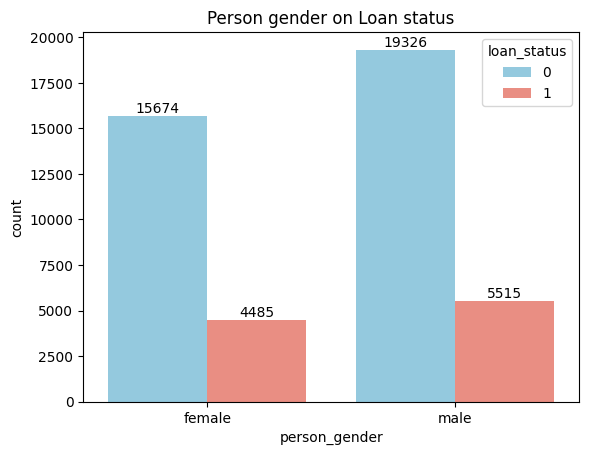

In [296]:
ax = sns.countplot(data=df, x="person_gender", hue="loan_status", palette=["skyblue", "salmon"])
ax.set_title('Person gender on Loan status')

for container in ax.containers:
    ax.bar_label(container)                   

plt.show()

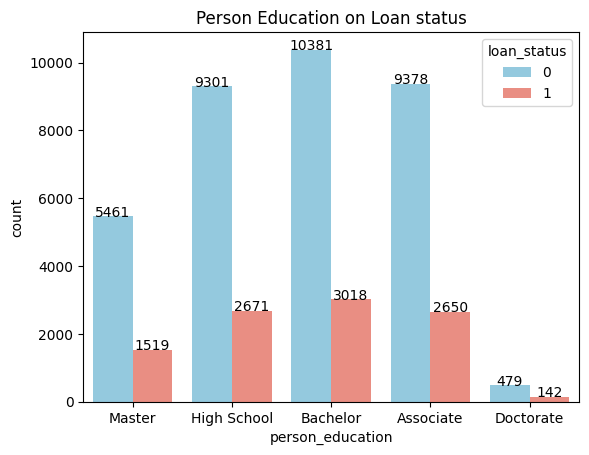

In [258]:
ax = sns.countplot(data=df, x="person_education", hue="loan_status", palette=["skyblue", "salmon"])
ax.set_title('Person Education on Loan status')
for p in ax.patches:
    if p.get_width() > 0:
        height = p.get_height()  # the count
        ax.text(x=p.get_x() + p.get_width()/2,
                y=height,
                s=int(height),
                ha="center")                     

plt.show()

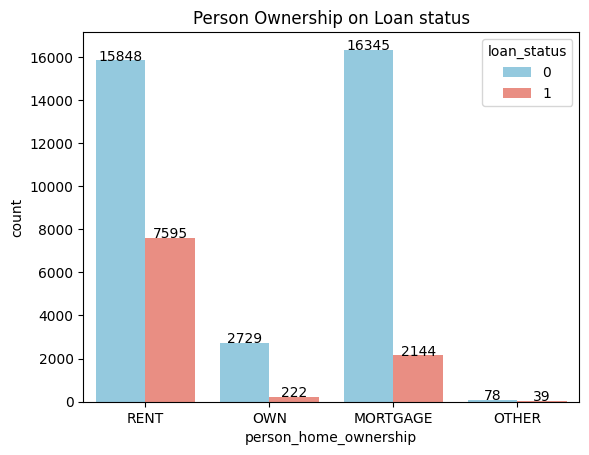

In [259]:
ax = sns.countplot(data=df, x="person_home_ownership", hue="loan_status", palette=["skyblue", "salmon"])
ax.set_title('Person Ownership on Loan status')
for p in ax.patches:
    if p.get_width() > 0:
        height = p.get_height()  # the count
        ax.text(x=p.get_x() + p.get_width()/2,
                y=height,
                s=int(height),
                ha="center")                     

plt.show()

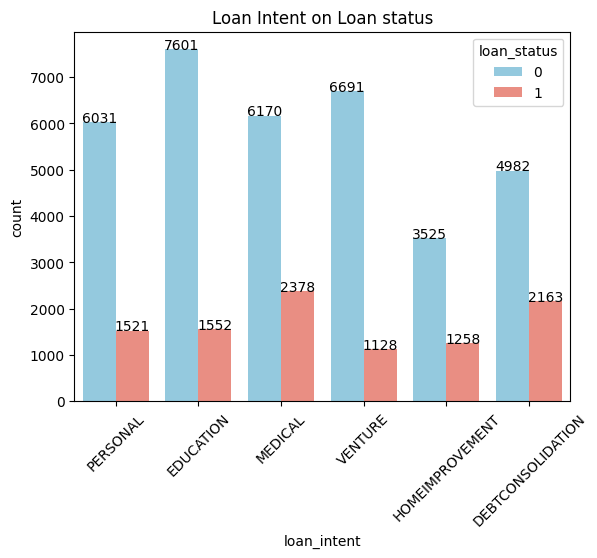

In [260]:
ax = sns.countplot(data=df, x="loan_intent", hue="loan_status", palette=["skyblue", "salmon"])
ax.set_title('Loan Intent on Loan status')
plt.xticks(rotation=45)
# ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right') 
for p in ax.patches:
    if p.get_width() > 0:
        height = p.get_height()  # the count
        ax.text(x=p.get_x() + p.get_width()/2,
                y=height,
                s=int(height),
                ha="center")                     

plt.show()

Rectangle(xy=(-0.4, 0), width=0.4, height=12142, angle=0)
Rectangle(xy=(0.6, 0), width=0.4, height=22858, angle=0)
Rectangle(xy=(5.55112e-17, 0), width=0.4, height=10000, angle=0)
Rectangle(xy=(0, 0), width=0, height=0, angle=0)
Rectangle(xy=(0, 0), width=0, height=0, angle=0)


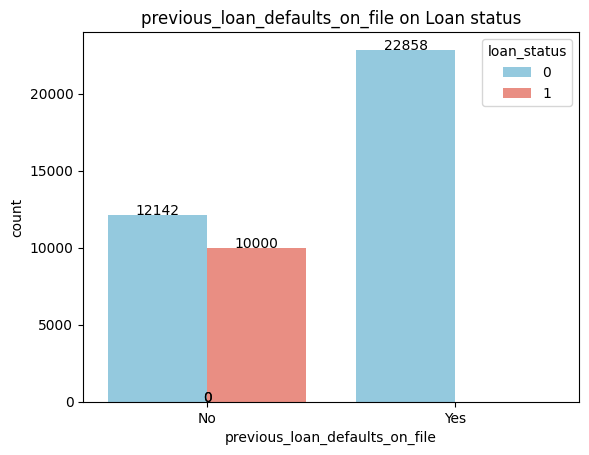

In [261]:
ax = sns.countplot(data=df, x="previous_loan_defaults_on_file", hue="loan_status", palette=["skyblue", "salmon"])
ax.set_title('previous_loan_defaults_on_file on Loan status')
for p in ax.patches[:]:
        print(p)
        height = p.get_height()  # the count
        ax.text(x=p.get_x() + p.get_width()/2,
                y=height,
                s=int(height),
                ha="center")                     

plt.show()

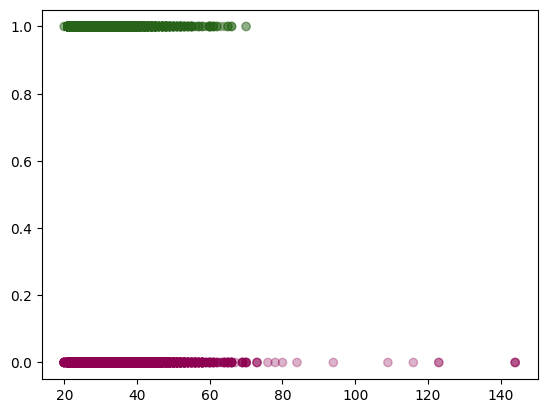

In [262]:
plt.scatter(df['person_age'], df['loan_status'], c=df['loan_status'], cmap="PiYG", alpha=.3)
plt.show()

In [263]:
data = origin_data.copy()
data['person_gender'] = data['person_gender'].map({'female': 1, 'male': 0})
data['previous_loan_defaults_on_file'] = data['previous_loan_defaults_on_file'].map({'No': 0, 'Yes': 1})
data.head()
loan_status_col = data['loan_status']
data = data.drop(columns="loan_status")
data.dtypes

person_age                        float64
person_gender                       int64
person_education                      str
person_income                     float64
person_emp_exp                      int64
person_home_ownership                 str
loan_amnt                         float64
loan_intent                           str
loan_int_rate                     float64
loan_percent_income               float64
cb_person_cred_hist_length        float64
credit_score                        int64
previous_loan_defaults_on_file      int64
dtype: object

In [264]:
df_encoded = pd.get_dummies(data, columns=["person_home_ownership"], dtype=int)
df_encoded.dtypes

person_age                        float64
person_gender                       int64
person_education                      str
person_income                     float64
person_emp_exp                      int64
loan_amnt                         float64
loan_intent                           str
loan_int_rate                     float64
loan_percent_income               float64
cb_person_cred_hist_length        float64
credit_score                        int64
previous_loan_defaults_on_file      int64
person_home_ownership_MORTGAGE      int64
person_home_ownership_OTHER         int64
person_home_ownership_OWN           int64
person_home_ownership_RENT          int64
dtype: object

In [265]:
data = df_encoded.select_dtypes(exclude="str")
data['loan_status'] = loan_status_col
data.dtypes

person_age                        float64
person_gender                       int64
person_income                     float64
person_emp_exp                      int64
loan_amnt                         float64
loan_int_rate                     float64
loan_percent_income               float64
cb_person_cred_hist_length        float64
credit_score                        int64
previous_loan_defaults_on_file      int64
person_home_ownership_MORTGAGE      int64
person_home_ownership_OTHER         int64
person_home_ownership_OWN           int64
person_home_ownership_RENT          int64
loan_status                         int64
dtype: object

<Axes: >

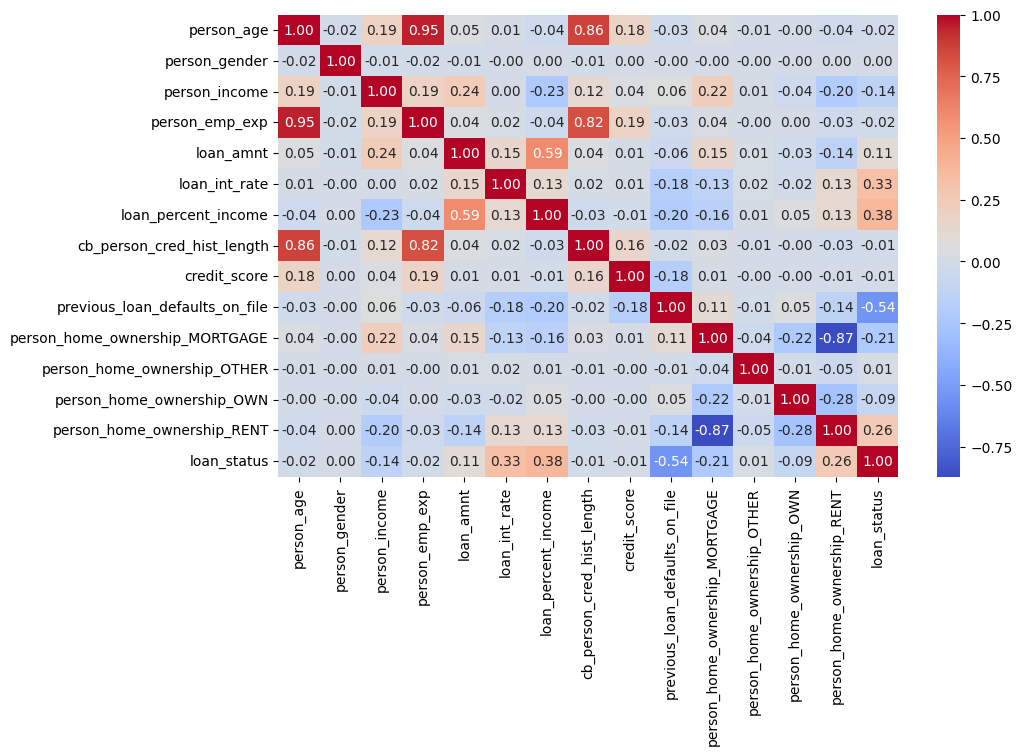

In [266]:
plt.figure(figsize=(10, 6))
sns.heatmap(data.corr(), annot=True, fmt=".2f", cmap="coolwarm")

In [267]:
# X = data.drop(columns=['loan_status', 'person_gender', 'person_emp_exp', 'loan_int_rate'])
X = data[['person_income', 'previous_loan_defaults_on_file', 'loan_amnt']]
y = data['loan_status']

In [268]:
X.dtypes

person_income                     float64
previous_loan_defaults_on_file      int64
loan_amnt                         float64
dtype: object

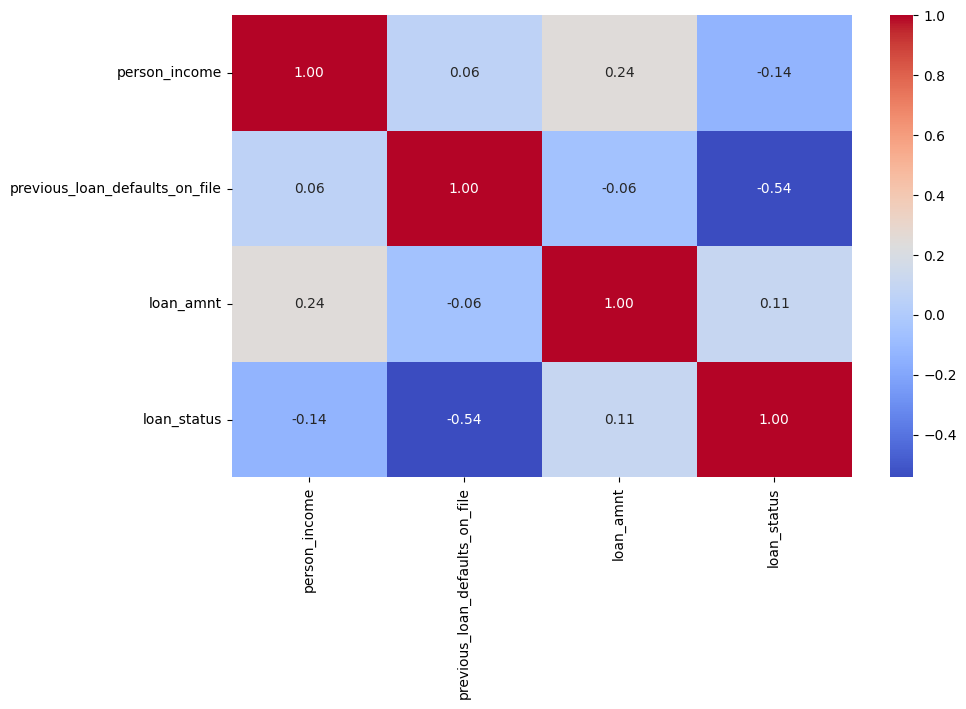

In [269]:
xy = X.copy()
xy['loan_status'] = y
plt.figure(figsize=(10, 6))
sns.heatmap(xy.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

In [270]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [271]:
print(X_train.size)
print(X_test.size)
print(X_test.size / X_train.size)

108000
27000
0.25


In [272]:
model = LogisticRegression()

In [273]:
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [274]:
y_pred = model.predict(X_test)

In [275]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(f"Precision: {precision_score(y_test, y_pred):.2f}")
print(f"Recall: {recall_score(y_test, y_pred):.2f}")
print(f"ROC_AUC: {roc_auc_score(y_test, y_pred):.2f}")

Accuracy: 0.85
Precision: 0.67
Recall: 0.64
ROC_AUC: 0.77


In [276]:
cm = confusion_matrix(y_test, y_pred)

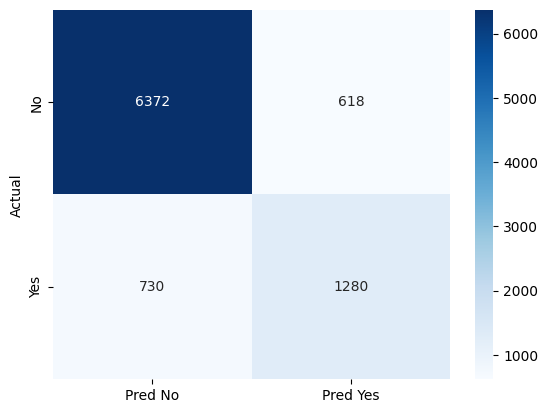

In [277]:
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Pred No", "Pred Yes"], yticklabels=["No", "Yes"])
plt.ylabel("Actual")
plt.show()

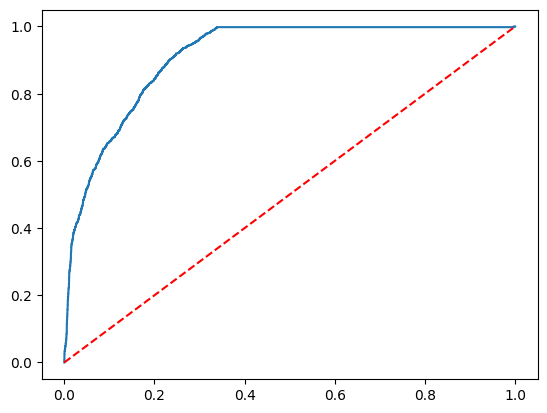

In [284]:
y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], color="red", linestyle="dashed")

In [285]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.91      0.90      6990
           1       0.67      0.64      0.66      2010

    accuracy                           0.85      9000
   macro avg       0.79      0.77      0.78      9000
weighted avg       0.85      0.85      0.85      9000



In [286]:
proba = model.predict_proba(X_test)
print(type(proba))

<class 'numpy.ndarray'>


In [287]:
print(proba.shape)

(9000, 2)


In [288]:
print(proba[0])

[0.75829771 0.24170229]
